# In-class Assignment 9.2

**Week 9 Wednesday**

#### &#x2705; Carter Hunt, Caleb Fowler, Keller McGough, Jack Seely

In PCA 9, you reviewed some information about **leptons** and **bosons**, and also learned about **mesons** and **baryons**. These are all types of particles that can decay or be observed during high-energy collisions. However, not all of them could result in a muon-antimuon pair.

In this ICA, you will work with your group to **identify the parent particles** whose peaks you have found in the muon data set.

---

## Part 1: Peaks of Interest

&#x2705; Based on your work in ICA 8.2, identify the peaks present in the `MuRun2010B.csv` data set.

In [4]:
import pandas as pd

df = pd.read_csv("/home/hub_data_share/data/MuRun2010B.csv", skiprows=5)

df.head()

,Run,Event,Type1,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,Type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2
0,146436,90830792,G,19.17120,3.817130,9.04323,-16.46730,9.81583,-1.289420,1.171390,1,T,5.43984,-0.362592,2.626990,-4.748490,2.65189,-1.345870,1.707960,1
1,146436,90862225,G,12.94350,5.125790,-3.98369,-11.19730,6.49180,-1.313350,-0.660674,-1,G,11.86360,4.789840,-6.262220,-8.864340,7.88403,-0.966622,-0.917841,1
2,146436,90644850,G,12.39990,-0.849742,9.40110,8.04015,9.43943,0.772580,1.660940,1,G,8.55532,-4.851550,6.976960,-0.983229,8.49797,-0.115445,2.178410,-1
3,146436,90678594,G,17.81320,-1.959590,2.80531,17.48110,3.42195,2.333500,2.180530,1,G,9.42174,4.365230,0.168017,8.347130,4.36846,1.403000,0.038471,1
4,146436,90686690,G,7.95664,7.097000,-1.31646,3.34613,7.21806,0.448399,-0.183411,1,T,5.44467,-1.341760,1.386470,5.090250,1.92941,1.697380,2.339810,-1


In [5]:
df['Etot'] = df['E1'] + df['E2']
df['px'] = df['px1 '] + df['px2']
df['py'] = df['py1'] + df['py2']
df['pz'] = df['pz1'] + df['pz2']
df['iM'] = (df['Etot']**2 - (df['px']**2 + df['py']**2 + df['pz']**2))**0.5

In [7]:
df.head()

,Run,Event,Type1,E1,px1,py1,pz1,pt1,eta1,phi1,...,pz2,pt2,eta2,phi2,Q2,Etot,px,py,pz,iM
0,146436,90830792,G,19.17120,3.817130,9.04323,-16.46730,9.81583,-1.289420,1.171390,...,-4.748490,2.65189,-1.345870,1.707960,1,24.61104,3.454538,11.670220,-21.215790,2.732339
1,146436,90862225,G,12.94350,5.125790,-3.98369,-11.19730,6.49180,-1.313350,-0.660674,...,-8.864340,7.88403,-0.966622,-0.917841,1,24.80710,9.915630,-10.245910,-20.061640,3.102325
2,146436,90644850,G,12.39990,-0.849742,9.40110,8.04015,9.43943,0.772580,1.660940,...,-0.983229,8.49797,-0.115445,2.178410,-1,20.95522,-5.701292,16.378060,7.056921,9.411457
3,146436,90678594,G,17.81320,-1.959590,2.80531,17.48110,3.42195,2.333500,2.180530,...,8.347130,4.36846,1.403000,0.038471,1,27.23494,2.405640,2.973327,25.828230,7.747046
4,146436,90686690,G,7.95664,7.097000,-1.31646,3.34613,7.21806,0.448399,-0.183411,...,5.090250,1.92941,1.697380,2.339810,-1,13.40131,5.755240,0.070010,8.436380,8.677264


In [8]:
Q0 = df[df['Q1'] != df['Q2']]

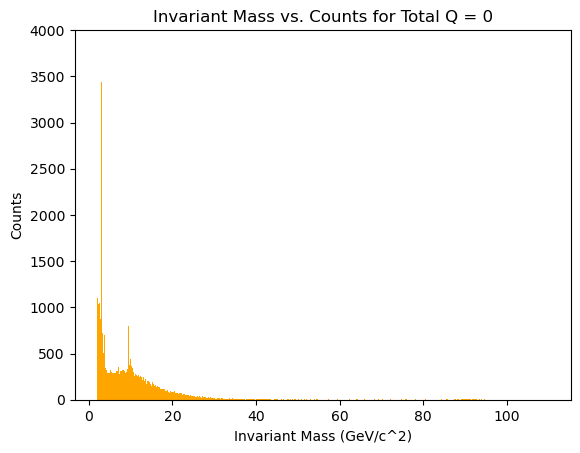

In [29]:
plt.hist(Q0['iM'], color = 'orange', bins = 1000)
plt.ylabel("Counts")
plt.xlabel("Invariant Mass (GeV/c^2)")
plt.ylim(0,4000)
plt.title("Invariant Mass vs. Counts for Total Q = 0");

Peak at ~3.2, ~9.4

---

## Part 2: Possible Parent Particles

&#x2705; What can you deduce about the properties of a parent particle that could be detectable in the data set?

That the parent particle/s likely have an invariant mass of ~3.2 or ~9.4. 

&#x2705; Using conservation laws, identify the possible parent particles, and match them to the peaks in your data set.

*Use the tables and resources from PCA 9 to help with this.*

From the table linked in PCA 9, and the invariant mass peaks on the histogram it would appear that the possible parent particles are J/Psi and Upsilon.

---

## Part 3: (Time Permitting) Data Set Selection

Remember, you must work as a group to make your way through the ICA. Only start Part 3 if you can do so as a whole group.

The MuRun2010B data set was compiled based on the selection criteria described here: https://opendata.cern.ch/record/700

However, there are other two-muon data sets with different selection criteria.

The Dimoun_SingleMu data set:
- Data: https://opendata.cern.ch/record/545/files/Dimuon_SingleMu.csv
- Selection criteria: https://opendata.cern.ch/record/38

The Dimuon_DoubleMu data set:
- Data: https://opendata.cern.ch/record/545/files/Dimuon_DoubleMu.csv
- Selection criteria: https://opendata.cern.ch/record/47

&#x2705; How do these data sets differ in terms of the selection criteria? What differences would you expect to see in the actual data?

The single muon set filtered the data for when at least one not-high energy muon and the double for at least two high-energy muons detected. I would expect a lot more data points in the SingleMu set, but I don't know otherwise how the "not high energy" single and "high energy" double sets would be different.

&#x2705; Read the SingleMu and DoubleMu data sets into the notebook using pandas read_csv. Compare the three data sets using the tools you've learned in this particle physics unit.

In [31]:
SMu = pd.read_csv("https://opendata.cern.ch/record/545/files/Dimuon_SingleMu.csv")
DMu = pd.read_csv("https://opendata.cern.ch/record/545/files/Dimuon_DoubleMu.csv")

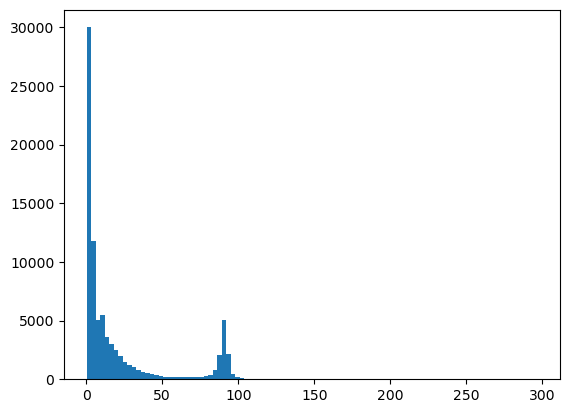

In [33]:
plt.hist(SMu['M'], bins = 100)
plt.show()

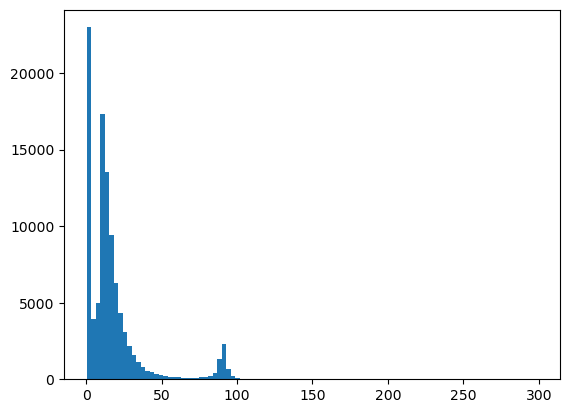

In [35]:
plt.hist(DMu['M'], bins = 100)
plt.show()